# 1. 인트로
## 1-1. RNN의 한계와 어텐션의 등장(복습)
RNN 계열 모델들은 데이터를 순차적으로 처리하는 특징을 가짐. 따라서, 장기 의존성 문제, 기울기 소실 문제, Seq2Seq는 Context Vector에 압축하면서 정보가 소실되는 문제 등 다양한 문제점을 가짐.

-> Attention 등장

### Attention
- 현재 시점에서 가장 중요한 부분에 더 높은 가중치를 부여하여 활용
- 출력 단어를 생성할 때 입력 문장 속 단어들 중 어떤 단어에 얼마나 집중할지 결정하는 기술
- Seq2Seq 방식과 비교했을 때, 가장 중요한 차이점은 바로 출력 시점마다 새로운 context vector를 동적으로 계산한다는 점입니다 → 병렬화!
- 과정 : 입력을 벡터 형태로 변환 → 단어별 중요도 계산 → 중요도에 따른 입력 정보 조합

### Attention 메커니즘의 장점
① 시간 경과에 대한 유연성 (vs RNN)  
- Attention은 모든 단어에서 다른 모든 단어로 직접 연결 → 아무리 멀리 떨어진 단어 사이의 관계라도 정보 손실 없음

② 공간에 대한 유연성 (vs CNN)
- Attention은 이미지의 모든 픽셀이 다른 모든 픽셀과 직접 연결 → 한 번에 전체 이미지의 전역적인 관계를 학습

③ 병렬화 (vs RNN)
- 순차 계산X → Attention은 self-attention에서 문장 내 모든 단어의 관계를 한번에, 독립적으로 계산 가능, 효율적 학습

⇒ 어텐션 메커니즘은 NLP 분야의 LLM뿐만 아니라, 이미지 생성에 사용되는 확산 모델이나 비전 분야에서 물체 감지, 이미지 분할과 같은 다양한 작업에서 우수한 성능을 발휘합니다!

## 1-2. Attention is All You Need

⇒ 반향: Attention을 쓰던 딥러닝 모델들이 대부분 Self-Attention 방식을 채택하게 됨.

① 논문 배경 : RNN과 RNN 기반 모델들의 한계점

② Transformer의 등장 

③ 논문에서 가장 중요한 발견

④ 파급효과
- LLM의 탄생: 트랜스포머는 BERT와 GPT라는 두 거대 모델의 직접적인 기반이 됨.
- NLP 평정: 번역, 요약, 챗봇 등 거의 모든 자연어 처리 분야에서 트랜스포머 기반 모델들이 표준으로 자리잡게 됨.
- 타 분야로의 확장: 트랜스포머의 성공은 AI를 NLP를 넘어 컴퓨터 비전(Vision Transformer), 음성 처리, 신약 개발 등 모든 영역으로 확장시킴.


## Transformer
- Transformer는 RNN의 순차적인 계산 방식을 완전히 버리고, 오직 어텐션(Attention)만으로 문장의 의미와 구조를 파악하는 모델입니다.
- Attention만으로 인코더와 디코더를 구현하였습니다.

### Transformer의 핵심 기술
1. Self-Attention : 문장 안에서 어떤 단어가 다른 단어들과 얼마나 중요한 관계를 맺고 있는지 한 번에 파악하는 기술
2. Multi-Head Attention : 셀프 어텐션을 여러 개의 머리(Head)로 동시에, 서로 다른 관점에서 실행합니다.
3. Positional Encoding : 단어의 위치 정보를 벡터에 추가하여 각 단어가 문장의 몇 번째 위치에 존재하는지 알 수 있습니다. 


# 2. Self-Attention
## 2-1. Query, Key, Value
- Q : Query
    - '질문' 또는 '요청'으로, 지금 당장 내가 알고 싶거나, 초점을 맞추고 있는 대상
    - In Attention : 문장 속 한 단어가 다른 단어들과의 관계를 파악하려 할 때, 그 기준이 되는 '나 자신'이 쿼리가 된다.
- K : Key
    - 키는 검색 대상이 되는 모든 정보들이 달고 있는 '이름표' 또는 '색인'
    - In Attention: 문장 내 모든 단어들이 각각 키의 역할을 수행하며, 현재 쿼리 단어와 얼마나 관련이 있는지 평가를 진행한다.
- V : Value
    - 밸류는 키와 한 쌍으로 묶여 있는 '실제 내용물'
    - In Attention: 특정 단어(Q)가 다른 단어(K)와 관련이 깊다고 판단되면, 그 단어(K)가 가진 실제 의미 정보(V)를 가져와 자신의 의미를 보강하는 데 사용한다.

### 2-2. 기존 Cross-Attention vs. Self-Attention
| 구분 | 기존 어텐션 (Cross-Attention) | 셀프 어텐션 (Self-Attention) |
| --- | --- | --- |
| 핵심 아이디어 | 번역할 문장을 슬쩍슬쩍 보면서 단어를 생성 | 문장 자체를 뜯어보며 내부 관계를 파악 |
| 작동 방식 | 하나의 시퀀스가 완전히 다른 시퀀스를 참고하여 정보를 만들어내는 메커니즘 | 한 문장 내 모든 단어끼리 서로의 관계를 계산 |
| 참조 대상 | 서로 다른 시퀀스 (인코더 ↔ 디코더) | 동일한 시퀀스 (문장 내부 ↔ 문장 내부) |
| 주요 목적 | 인코더-디코더 연결, 정보 병목 현상 해소 | 시퀀스 내부의 문맥 및 의존 관계 파악 |
| 기반 아키텍처 | RNN (LSTM, GRU) | 트랜스포머 (Attention Only) |
| 병렬 처리 | 불가능 (순차적)  | 가능  |

- Self-Attention 과정
1. 단어의 프로필 만들기 (벡터 임베딩)
2. 단어 간 관계 점수 계산 (내정 및 정렬 점수)
3. 중요도 배분 (소프트맥스 & 어텐션 가중치)
4. 새로운 벡터 생성

### 2-3. Scaled Dot-Product Attention
- Dot-Product Attention은 Attention Score를 계산하는 가장 기본적인 방법 중 하나입니다. 쿼리(Query)와 키(Key) 벡터를 내적(Dot Product)하여 유사도를 구합니다.
- Scaled Dot-Product Attention은 Dot-Product Attention 과정에서 내적을 진행한 후, 값의 크기를 맞추는 스케일링 과정을 추가
- 과정
1. 쿼리(Q) 벡터와 모든 키(K) 벡터를 각각 내적하여 유사도 계산을 진행   
→ Attention Score = Q · K  
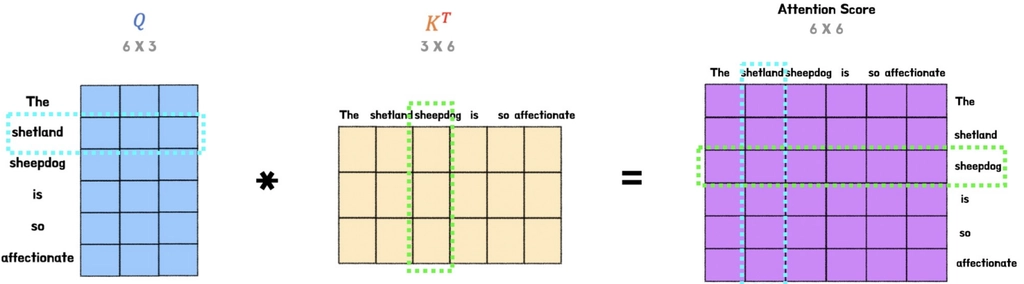  
2. **계산된 값을 $\sqrt{d_K}$ 로 나누어 스케일링을 진행한다**
3. 계산된 값에 Softmax 함수를 적용하여 총합이 1인 Attention Weight 산출  
4. 이 가중치를 밸류(V) 벡터에 곱하여 최종 결과값을 계산  
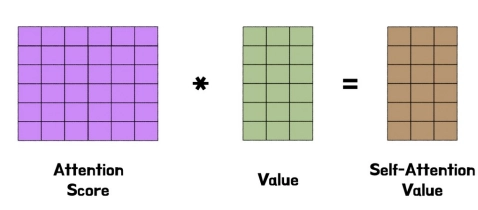

#### Scaled Dot-Product Attention 계산의 결과로 얻어지는 벡터
- Cross-Attention : 현재 생성 중인 단어가, 입력 문장에서 어떤 단어들에 집중해야 하는지를 반영한 Context Vector
- Self-Attention : 문장 내 다른 단어들과의 관계를 반영한 문맥적 표현


# 3. Multi-Head Attention
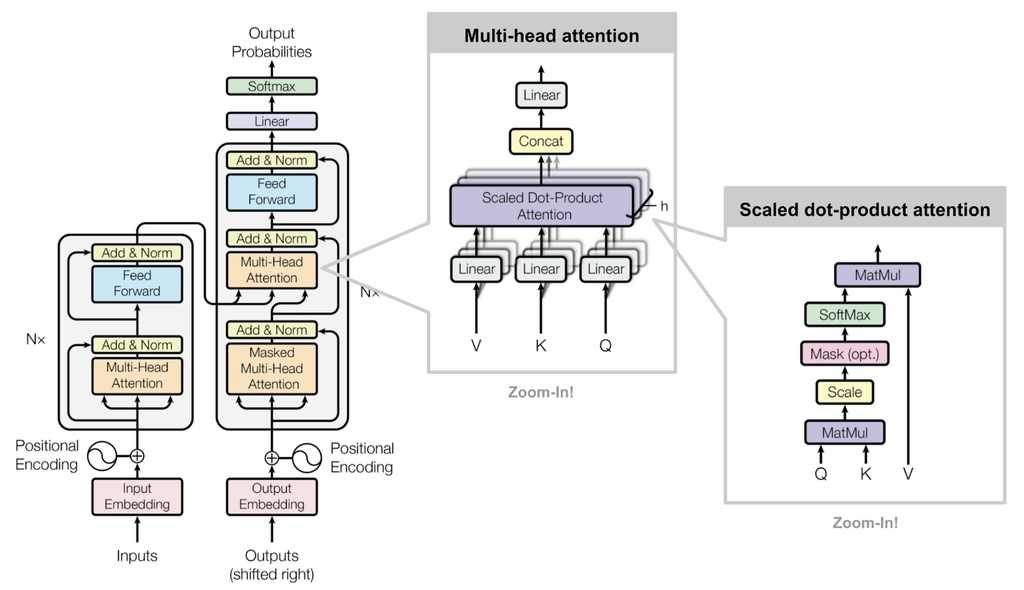
- Encoder(왼쪽 박스 내부)에서는 Multi-Head Attention이 한 번 사용됩니다.
- Decoder(오른쪽 박스 내부)에서는 Multi-Head Attention이 두 번 사용됩니다.
    - Masked Multi-Head Attention: 아직 생성되지 않은 미래 단어를 보지 못하도록 가리고, 현재까지 생성된 단어들만 참고합니다.
    - Encoder-Decoder Attention:  Decoder가 출력을 생성할 때, Encoder가 이해한 입력 문장 정보를 참고합니다.

## 3-1. Why Multi-Head Attention?
- Multi-Head Attention은 한 단어와 다른 단어 간의 관계를 여러 차원으로 나누어 병렬로 학습합니다. 
- Attention is all you need 에서는 512차원의 입력 벡터를 64차원씩 8개의 벡터로 나누고, Attention 스코어를 병렬로 여러 번 계산 하는데, 이 과정이 Multi-Head Attention입니다.
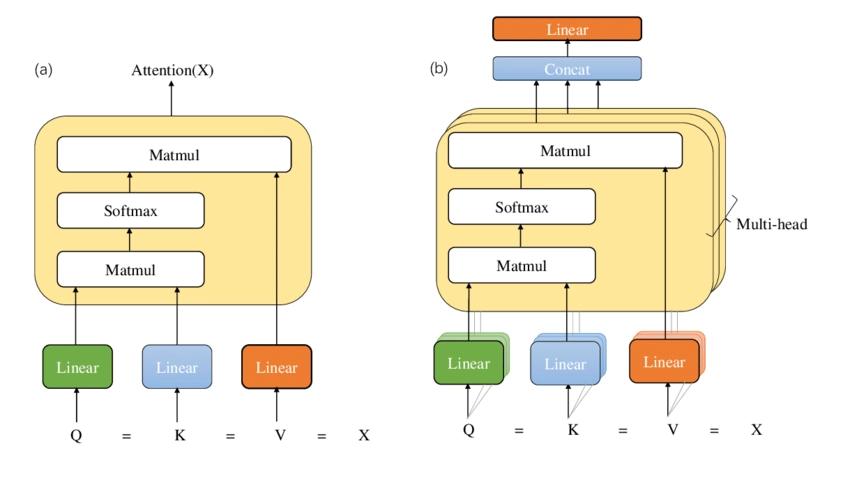  
(a): Single-Head Attention / (b): Multi-Head Attention 

## 3-2. Multi-Head Attention 작동 방식
1. 분할 (Projection) - 8명의 헤드에 단어 벡터 할당
- 가장 먼저, 'love'라는 단어를 나타내는 하나의 512차원 벡터가 들어옵니다. 멀티-헤드 어텐션은 이 큰 벡터를 통째로 처리하지 않고, 이 벡터를 8개의 작은 벡터 그룹(Q, K, V)으로 투영(projection) 하여 8개의 서로 다른 관점으로 나눕니다.
- 이제 512차원의 큰 문제 하나가, 서로 다른 관점을 담은 8개의 독립적인 64차원짜리 작은 벡터(Q, K, V 세트)들로 분할되었습니다.
2. 병렬 어텐션 계산 - 각 헤드들이 각자 분석 수행
- 이제 8개의 헤드는 서로에게 전혀 간섭하지 않고, 병렬로 Scaled Dot-Product Attention을 계산합니다. 
- ① 점수 계산 (Score) -> ② 크기 조절 (Scale) -> ③ 가중치 변환 (Softmax) -> ④ 가중합 (Weighted Sum)
- 이 결과로 헤드 1의 관점에서 문맥을 이해한 64차원의 결과 벡터 Attention_Output_1이 나옵니다.
3. 결합 및 최종 투영
- ① 결합 (Concatenate) -> ② 최종 투영 (Final Projection)
- 이 Final_Output이 바로 'love'라는 단어에 대한 Multi-Head Attention 레이어의 최종 출력 벡터입니다. 이 벡터는 8개의 서로 다른 관점에서 분석된 정보가 조화롭게 융합된, 매우 풍부한 문맥적 의미를 담고 있습니다.


# 4. Transformer 전체 아키텍처
## 4-1. 트랜스포머의 전처리 단계
- 트랜스포머는 텍스트를 입력(Inputs)받고, 그 텍스트를 토큰화하고, 토큰들을 임베딩하고, Positional Encoding으로 순서 정보를 추가하여 인코더 레이어에서 실질적인 연산을 수행합니다.

1. 토큰화 (Tokenization)
- 토큰화는 입력 텍스트를 모델이 처리할 수 있는 단위(tokens)로 나누는 첫 번째 단계입니다.

2. 임베딩 (Embedding)
- 토큰화된 각 단위(토큰)는 임베딩 단계에서 숫자의 벡터로 변환됩니다.
- 벡터의 길이 ⇒ 벡터의 차원
- 임베딩의 가장 중요한 원리는 단어의 의미를 공간적으로 표현하는 것입니다.
- 유사한 단어 ⇒ 유사한 숫자
- 방법 예시 : Word2Vec

3. Positional Encoding
- Positional Encoding은 단어들의 순서 정보 를 임베딩 벡터에 추가하는 단계!
- 단어들은 문법적 측면이나, 문맥을 파악하기 위해서나 등장한 순서가 매우 중요하기 때문에, 이 순서 정보, 즉 위치 정보 를 제공하기 위해 positional encoding을 사용합니다.
- 위치 벡터 생성 -> 위치 계산 -> 임베딩에 합산

## 4-2. 트랜스포머의 Encoder와 Decoder
### 1. Encoder
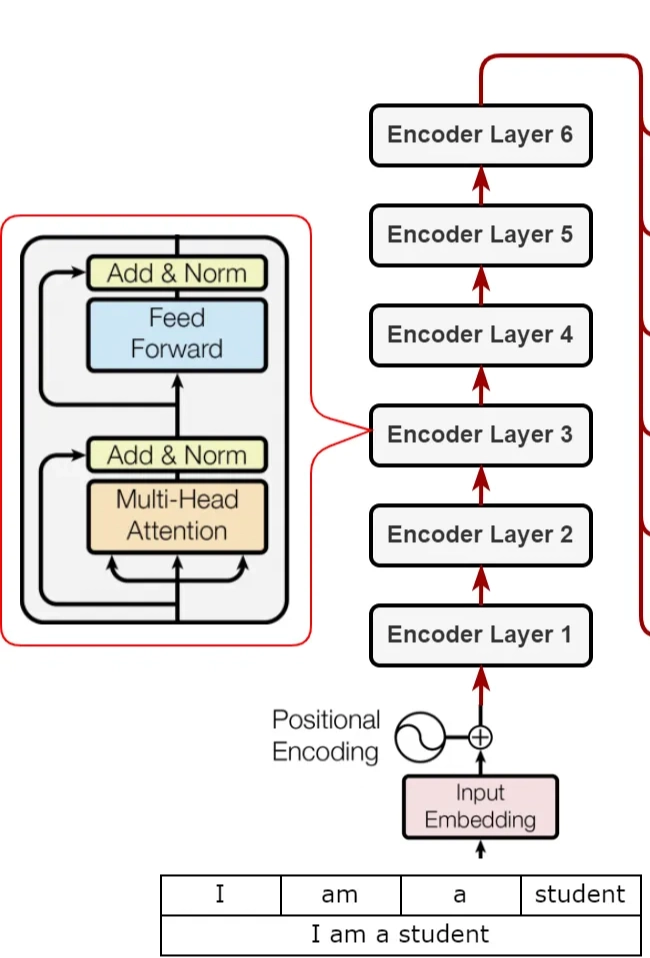
- 트랜스포머의 Encoder는 입력 문장을 이해하고 요약된 의미 벡터로 변환하는 역할을 합니다. 
- 전처리 과정(토큰화, 임베딩, Positional Encoding) 및 인코더 레이어(Multi-Head Attention, Feed Forward Layer)로 구성되어 있습니다.
- Feed-Forward Layer (FFN)
    - 입력 벡터의 차원을 확장하고 비선형 변환(ex: ReLU)을 적용하여 새로운 표현을 생성하는 신경망 구조
- ADD & Norm
    - Residual connections (잔차 연결) : 입력 값을 그대로 출력에 더해 주는 것
        - a→b→c→d와 같이 여러 층을 거쳐야 했던 과정이 a→d로 축약되어서, layer가 많이 쌓여도 학습이 잘되게 됩니다. 
    - Layer Normalization (층 정규화) : 입력 벡터의 평균과 분산을 사용해서 정규화하는 것
        - → 학습을 안정화하고 모델이 빠르게 수렴하게 만들어 줍니다.

### 2. Decoder
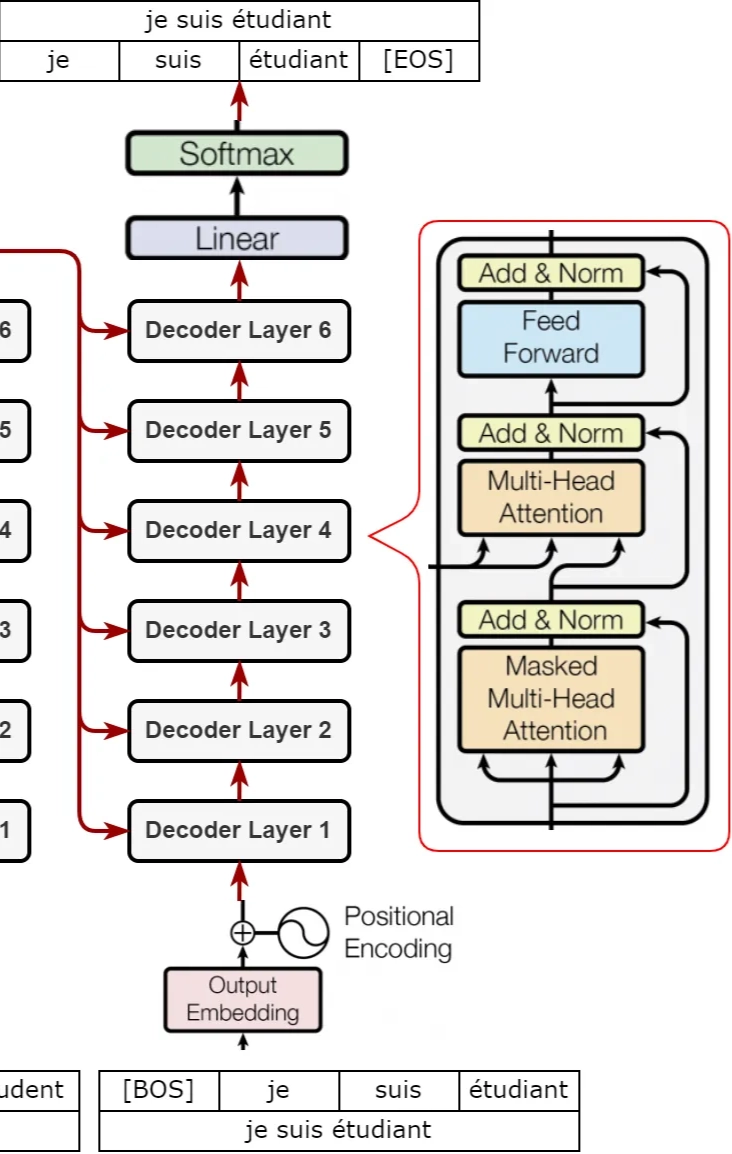
- 트랜스포머의 Decoder는 Encoder가 분석한 입력 문장의 의미 벡터를 받아서 출력 문장을 순차적으로 생성하는 역할을 담당합니다.
- 전처리 과정, 디코더 레이어, 선형 레이어와 소프트맥스 레이어로 이루어져 있습니다.
- Masked Multi-Head Attention : 미래 시점의 단어 정보를 참고하지 못하도록 마스크(mask)를 적용하는 어텐션 메커니즘
    - 트랜스포머의 디코더는 시퀀스를 왼쪽에서 오른쪽으로(autogressive) 생성하며, 모델이 이미 생성된 단어들(과거 정보)만을 기반으로 다음 단어를 예측하도록 강제
- Encoder-Decoder Attention (Cross-Attention) : 디코더가 인코더의 출력(Context)을 참고하면서 현재 생성 중인 단어를 입력 문장의 의미와 연결하는 과정
    - 디코더가 입력 문장 중 어떤 부분에 주목해야 하는지를 학습합니다.

| 벡터 종류 | 어디서 오는가 |
| --- | --- |
| **Query (Q)** | 디코더의 이전 서브레이어 출력 |
| **Key (K)**, **Value (V)** | 인코더의 최종 출력 (Context Vector) |


## 4-3. 전체 모델 및 데이터 흐름
1. 입력 준비: 문장을 [의미 + 위치] 벡터로 바꾸기
2. 인코더: 입력 문장의 [문맥적 의미] 깊이 이해하기
3. 디코더: 번역 문장을 [한 단어씩] 생성하기

I love you -> 나는 당신을 사랑해

번역 과정으로 연상하기